In [1]:
import os
import random
import warnings

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, matthews_corrcoef
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


In [2]:
chronic_kidney_disease = fetch_ucirepo(id=336)

X_raw = chronic_kidney_disease.data.features
y_raw = chronic_kidney_disease.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Shape:", df.shape)
print("\nMissing values (top 12):")
miss = df.isnull().sum().sort_values(ascending=False)
print(pd.DataFrame({"n_missing": miss, "pct": (miss / len(df) * 100).round(1)}).head(12))

df.head()

Shape: (400, 25)

Missing values (top 12):
      n_missing   pct
rbc         152  38.0
rbcc        131  32.8
wbcc        106  26.5
pot          88  22.0
sod          87  21.8
pcv          71  17.8
pc           65  16.2
hemo         52  13.0
su           49  12.2
sg           47  11.8
al           46  11.5
bgr          44  11.0


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## ۲) پاک‌سازی عمیق مقادیر متنی

در نسخهٔ قبلی فقط `strip` انجام می‌شد؛ اما این داده چند نوع آلودگی دیگر دارد که با `value_counts` قابل مشاهده است:

- کاراکتر `tab` چسبیده به مقدار (مثل `"\tno"` در ستون `dm` و `"ckd\t"` در ستون `class`)
- عدم یکسان‌سازی بزرگی/کوچکی حروف
- مقادیر خارج از مجموعهٔ مجاز هر ستون

اینجا یک تابع پاک‌سازی مرکزی می‌نویسیم که همهٔ این موارد را یکجا حل می‌کند و بعد از اجرا، «حافظهٔ»
پاک‌سازی را چاپ می‌کند تا مطمئن شویم چیزی از قلم نیفتاده است.

In [3]:
# Allowed value sets for each categorical column (clinical knowledge)
ALLOWED_VALUES = {
    "rbc":   {"normal", "abnormal"},
    "pc":    {"normal", "abnormal"},
    "pcc":   {"present", "notpresent"},
    "ba":    {"present", "notpresent"},
    "htn":   {"yes", "no"},
    "dm":    {"yes", "no"},
    "cad":   {"yes", "no"},
    "appet": {"good", "poor"},
    "pe":    {"yes", "no"},
    "ane":   {"yes", "no"},
    "class": {"ckd", "notckd"},
}

def deep_clean_text(value: str, allowed: set) -> str | None:
    # Normalize a raw categorical value: remove tabs/spaces, lowercase, validate.
    if pd.isna(value):
        return None
    v = str(value).replace("\t", "").replace(" ", "").strip().lower()
    return v if v in allowed else None

cleaned_cells = 0
for col, allowed in ALLOWED_VALUES.items():
    before = df[col].copy()
    df[col] = df[col].apply(lambda v: deep_clean_text(v, allowed))
    n_fixed = int((before.astype(str) != df[col].astype(str)).sum()
                  - before.isna().sum() + df[col].isna().sum())
    if n_fixed > 0:
        print(f"column '{col}': {n_fixed} value(s) normalized/repaired")
        cleaned_cells += n_fixed

print(f"\nTotal repaired cells: {cleaned_cells}")

print("\n--- dm after deep cleaning ---")
print(df["dm"].value_counts(dropna=False))
print("\n--- htn after deep cleaning ---")
print(df["htn"].value_counts(dropna=False))
print("\n--- class after deep cleaning ---")
print(df["class"].value_counts(dropna=False))

column 'rbc': 152 value(s) normalized/repaired
column 'pc': 65 value(s) normalized/repaired
column 'pcc': 4 value(s) normalized/repaired
column 'ba': 4 value(s) normalized/repaired
column 'htn': 2 value(s) normalized/repaired
column 'dm': 3 value(s) normalized/repaired
column 'cad': 2 value(s) normalized/repaired
column 'appet': 1 value(s) normalized/repaired
column 'pe': 1 value(s) normalized/repaired
column 'ane': 1 value(s) normalized/repaired
column 'class': 2 value(s) normalized/repaired

Total repaired cells: 237

--- dm after deep cleaning ---
dm
no      261
yes     137
None      2
Name: count, dtype: int64

--- htn after deep cleaning ---
htn
no      251
yes     147
None      2
Name: count, dtype: int64

--- class after deep cleaning ---
class
ckd       250
notckd    150
Name: count, dtype: int64


## ۳) حذف ردیف‌های بدون برچسب

دو رکورد، هیچ مقداری برای `dm` و `htn` (و `cad`) ندارند؛ چون برچسب آموزش ندارند، از داده حذف می‌شوند.
(در نسخهٔ قبلی همین کار انجام می‌شد.)

In [4]:
before_rows = len(df)
df = df.dropna(subset=["dm", "htn"]).reset_index(drop=True)
print(f"Rows: {before_rows} -> {len(df)}")

y_dm  = (df["dm"]  == "yes").astype(int)
y_htn = (df["htn"] == "yes").astype(int)

print("\nDiabetes (dm):")
print(y_dm.value_counts())
print("\nHypertension (htn):")
print(y_htn.value_counts())

joint = y_dm.astype(str) + "_" + y_htn.astype(str)
print("\nJoint distribution (dm_htn):")
print(joint.value_counts())

Rows: 400 -> 398

Diabetes (dm):
dm
0    261
1    137
Name: count, dtype: int64

Hypertension (htn):
htn
0    251
1    147
Name: count, dtype: int64

Joint distribution (dm_htn):
0_0    220
1_1    106
0_1     41
1_0     31
Name: count, dtype: int64


## ۴) اصلاح خطاهای ورود داده (جابه‌جایی ممیز)

با بررسی دامنهٔ مقادیر عددی، دو خطای واضحِ ورود داده پیدا می‌شود:

- `sod` (سدیم سرم): یک مقدار `4.5` ثبت شده، در حالی که دامنهٔ بالینی سدیم حدود ۱۰۰ تا ۱۶۰ است →
  به‌وضوح `45` بوده و ممیز جابه‌جا شده است.
- `pot` (پتاسیم سرم): مقادیر `39` و `47` ثبت شده، در حالی که دامنهٔ بالینی پتاسیم حدود ۲/۵ تا ۷ است →
  به‌وضوح `3.9` و `4.7` بوده‌اند.

در نسخهٔ قبلی این مقادیر بدون اصلاح، هم imputation و هم آموزش مدل را منحرف می‌کردند.

In [5]:
# Clinical plausibility ranges -> detect decimal-shift errors
CLINICAL_RANGES = {
    "age": (1, 120), "bp": (40, 260), "bgr": (30, 600), "bu": (1, 500),
    "sc": (0.1, 100), "sod": (100, 180), "pot": (1.5, 12),
    "hemo": (3, 25), "pcv": (5, 70), "wbcc": (1000, 100000), "rbcc": (1, 10),
}

print("Out-of-range values BEFORE repair:")
for col, (lo, hi) in CLINICAL_RANGES.items():
    bad = df[(df[col] < lo) | (df[col] > hi)][col]
    if len(bad):
        print(f"  {col}: {bad.tolist()}")

# Repair obvious decimal shifts (x10 or /10)
df.loc[df["sod"] < CLINICAL_RANGES["sod"][0], "sod"] *= 10
df.loc[df["pot"] > CLINICAL_RANGES["pot"][1], "pot"] /= 10

print("\nAfter repair:")
for col in ["sod", "pot"]:
    bad = df[(df[col] < CLINICAL_RANGES[col][0]) | (df[col] > CLINICAL_RANGES[col][1])][col]
    print(f"  {col}: out-of-range count = {len(bad)}")

Out-of-range values BEFORE repair:
  bgr: [22.0]
  sod: [4.5]
  pot: [39.0, 47.0]

After repair:
  sod: out-of-range count = 1
  pot: out-of-range count = 0


## ۵) تحلیل داده‌های پرت (IQR)

مثل نسخهٔ قبلی، داده‌های پرت با قانون IQR شناسایی می‌شوند؛ اما در نسخهٔ جدید **آن‌ها را حذف یا جایگزین نمی‌کنیم**، چون:

1. مدل‌های درختی (XGBoost/LightGBM) ذاتاً در برابر مقادیر پرت مقاوم‌اند.
2. برای شبکهٔ عصبی از `QuantileTransformer` استفاده می‌شود که توزیع را نرمال می‌کند و اثر پرت‌ها را خنثی می‌سازد.
3. در داده‌های بالینی، مقدار «پرت» گاهی همان سیگنال بیماری است (مثلاً کراتینین بسیار بالا).

بنابراین این بخش صرفاً تحلیل و مستندسازی است.

In [6]:
X_full = df.drop(columns=["dm", "htn", "class"])
num_cols_all = X_full.select_dtypes(include="number").columns.tolist()
cat_cols_all = X_full.select_dtypes(include="object").columns.tolist()

Q1 = X_full[num_cols_all].quantile(0.25)
Q3 = X_full[num_cols_all].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((X_full[num_cols_all] < (Q1 - 1.5 * IQR)) |
                  (X_full[num_cols_all] > (Q3 + 1.5 * IQR))).sum()
outlier_df = pd.DataFrame({
    "outlier_count": outlier_counts,
    "outlier_percent": (outlier_counts / len(X_full) * 100).round(1),
}).sort_values("outlier_count", ascending=False)
outlier_df

,outlier_count,outlier_percent
su,61,15.3
sc,51,12.8
bu,38,9.5
bp,36,9.0
bgr,34,8.5
sod,16,4.0
wbcc,10,2.5
age,7,1.8
pot,2,0.5
hemo,1,0.3


## ۶) مهندسی ویژگی

نسبت‌ها و فلگ‌های زیر از دانش بالینی آمده‌اند و در نسخهٔ قبلی وجود نداشتند:

| ویژگی جدید | تعریف | چرا مفید است |
|---|---|---|
| `bu_sc_ratio` | BUN ÷ کراتینین | شاخص کلاسیک عملکرد کلیه (نسبت اوره به کراتینین) |
| `hemo_x_pcv` | هموگلوبین × هماتوکریت | شاخص ترکیبی کم‌خونی — کم‌خونی با پیشرفت CKD ارتباط دارد |
| `bgr_x_su` | قند خون × قند ادرار | تقویت سیگنال دیابت از دو منبع مستقل |
| `bp_high` | فشار ≥ ۹۰ | فلگ بالینی فشار خون بالا |
| `bgr_high` | قند خون ≥ ۱۸۰ | آستانهٔ بالینی هیپرگلیسمی |
| `anemia` | هموگلوبین < ۱۲ | فلگ بالینی کم‌خونی |
| `*_missing` | نشانگر گمبودن مقدار | الگوی گم‌شدن داده در این دیتاست خودش اطلاعات دارد |

نکتهٔ مهم: همهٔ این عملیات **سطری** هستند (به ردیف‌های دیگر نگاه نمی‌کنند)؛ بنابراین هیچ نشتی اطلاعاتی
(data leakage) بین train و test رخ نمی‌دهد.

In [7]:
def engineer_features(Xin: pd.DataFrame) -> pd.DataFrame:
    # Add clinically-motivated ratios, risk flags and missing indicators.
    Xe = Xin.copy()

    # Ratios / interactions
    Xe["bu_sc_ratio"] = Xe["bu"] / (Xe["sc"] + 1e-3)
    Xe["hemo_x_pcv"]  = Xe["hemo"] * Xe["pcv"]
    Xe["bgr_x_su"]    = Xe["bgr"] * (Xe["su"] + 1)

    # Clinical risk flags (NaN-aware)
    Xe["bp_high"]  = np.where(Xe["bp"].isna(),  np.nan, (Xe["bp"]  >= 90).astype(float))
    Xe["bgr_high"] = np.where(Xe["bgr"].isna(), np.nan, (Xe["bgr"] >= 180).astype(float))
    Xe["anemia"]   = np.where(Xe["hemo"].isna(), np.nan, (Xe["hemo"] < 12).astype(float))

    # Missing indicators for high-missing-rate columns
    for c in ["rbc", "rbcc", "wbcc", "sod", "pot", "pcv", "hemo", "bgr", "bp"]:
        Xe[f"{c}_missing"] = Xe[c].isna().astype(int)

    return Xe

X_eng = engineer_features(X_full)
new_feats = [c for c in X_eng.columns if c not in X_full.columns]
print(f"Features: {X_full.shape[1]} -> {X_eng.shape[1]}")
print("New features:", new_feats)

Features: 22 -> 37
New features: ['bu_sc_ratio', 'hemo_x_pcv', 'bgr_x_su', 'bp_high', 'bgr_high', 'anemia', 'rbc_missing', 'rbcc_missing', 'wbcc_missing', 'sod_missing', 'pot_missing', 'pcv_missing', 'hemo_missing', 'bgr_missing', 'bp_missing']


## ۷) ارتباط ویژگی‌ها با اهداف

همبستگی پیرسون ویژگی‌های عددی (شامل ویژگی‌های جدید) با دو هدف:

In [8]:
corr_df = X_eng.select_dtypes(include="number").copy()
corr_df["diabetes"] = y_dm
corr_df["hypertension"] = y_htn

corr_with_targets = corr_df.corr()[["diabetes", "hypertension"]].drop(
    index=["diabetes", "hypertension"])
corr_with_targets.sort_values("diabetes", ascending=False).round(3)

,diabetes,hypertension
bgr_high,0.535,0.383
bgr,0.526,0.390
su,0.523,0.322
bgr_x_su,0.510,0.348
anemia,0.455,0.540
al,0.414,0.526
age,0.369,0.400
bu,0.318,0.394
rbc_missing,0.290,0.256
bp_high,0.288,0.356


## ۸) کدگذاری متغیرهای طبقه‌ای + تقسیم آموزش / آزمون

قبل از مدل‌سازی، ستون‌های طبقه‌ای به کد عددی تبدیل می‌شوند (`NaN` برای مقادیر گم‌شده حفظ می‌شود تا
مدل‌های درختی خودشان الگوی گم‌شدگی را یاد بگیرند).

سپس تقسیم با همان پروتکل نسخهٔ قبلی انجام می‌شود: `test_size=0.2`، `random_state=42` و stratify روی
برچسب ترکیبی `dm_htn` تا توازن کلاس‌ها در هر دو هدف حفظ شود و نتیجه‌ها مستقیماً با نسخهٔ قبل
قابل مقایسه باشند.

In [9]:
# Ordinal encoding for categorical columns (missing stays NaN)
CAT_CODE_MAP = {}
for c in cat_cols_all:
    cat = X_eng[c].astype("category")
    CAT_CODE_MAP[c] = list(cat.cat.categories)
    X_eng[c] = cat.cat.codes.astype(float).replace(-1, np.nan)

print("Categorical columns encoded:")
for c, cats in CAT_CODE_MAP.items():
    print(f"  {c}: {cats}")

stratify_target = y_dm.astype(str) + "_" + y_htn.astype(str)

idx_train, idx_test = train_test_split(
    np.arange(len(X_eng)), test_size=0.2,
    random_state=RANDOM_STATE, stratify=stratify_target)

X_train, X_test = X_eng.iloc[idx_train].reset_index(drop=True), X_eng.iloc[idx_test].reset_index(drop=True)
y_dm_train, y_dm_test = y_dm.iloc[idx_train].to_numpy(), y_dm.iloc[idx_test].to_numpy()
y_htn_train, y_htn_test = y_htn.iloc[idx_train].to_numpy(), y_htn.iloc[idx_test].to_numpy()

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Test positives  -> dm: {y_dm_test.sum()} / {len(y_dm_test)} | htn: {y_htn_test.sum()} / {len(y_htn_test)}")

Categorical columns encoded:
  rbc: ['abnormal', 'normal']
  pc: ['abnormal', 'normal']
  pcc: ['notpresent', 'present']
  ba: ['notpresent', 'present']
  cad: ['no', 'yes']
  appet: ['good', 'poor']
  pe: ['no', 'yes']
  ane: ['no', 'yes']

Train: (318, 37) | Test: (80, 37)
Test positives  -> dm: 28 / 80 | htn: 30 / 80


## ۹) پیش‌پردازش ویژهٔ شبکهٔ عصبی

پیش‌پردازش نسخهٔ جدید نسبت به قبلی قوی‌تر است:

1. **Imputation با نشانگر:** علاوه بر جایگزینی با میانهٔ *فقطِ* دادهٔ آموزش، ستون‌های دودوییِ
   «این مقدار گم بوده» اضافه می‌شوند (در نسخهٔ قبل `add_indicator=True` بود ولی نسخهٔ جدید تعداد ستون‌های
   نشانگر را با مهندسی ویژگی بالا برده و همین کار را برای مدل‌های درختی هم تکرار می‌کند).
2. **QuantileTransformer:** نگاشت هر ویژگی به توزیع نرمال؛ هم مقیاس‌ها را یکسان می‌کند و هم اثر
   داده‌های پرت را خنثی می‌کند.
3. **جلوگیری از نشتی:** هر دو گام فقط با `fit` روی دادهٔ آموزش و سپس `transform` روی دادهٔ آزمون اجرا می‌شوند.

In [10]:
imputer = SimpleImputer(strategy="median", add_indicator=True)
quantile_tf = QuantileTransformer(
    output_distribution="normal",
    n_quantiles=min(300, len(X_train)),   # n_quantiles cannot exceed n_samples
    random_state=RANDOM_STATE,
)

X_train_nn = quantile_tf.fit_transform(imputer.fit_transform(X_train))
X_test_nn  = quantile_tf.transform(imputer.transform(X_test))

print(f"NN input dims: {X_train_nn.shape[1]} "
      f"({X_train.shape[1]} features + missing-indicator columns)")

NN input dims: 64 (37 features + missing-indicator columns)


## ۱۰) شبکهٔ عصبی چندخروجی بهبودیافته

بهبودهای نسخهٔ جدید نسبت به شبکهٔ قبلی:

| مورد | قبلی | جدید |
|---|---|---|
| معماری | 96→48→(24) | 128→64→32 با BatchNorm قبل از Activation |
| Regularization | L2(1e-4) | L2(3e-4) + Dropout پلکانی (0.35/0.25/0.15) |
| Loss | BinaryCE | BinaryCE + **label smoothing=0.05** (مقاوم‌سازی در برابر نویز برچسب) |
| تعادل کلاس | sample weight | class weight محاسبه‌شده از خودِ fold |
| بهینه‌سازی | Adam(1e-3) | Adam(1e-3) + ReduceLROnPlateau + EarlyStopping با patience 40 |

In [11]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(RANDOM_STATE)

def build_multioutput_nn(n_features: int) -> Model:
    # Multi-output NN with two sigmoid heads (diabetes / hypertension).
    inputs = Input(shape=(n_features,), name="input")

    x = Dense(128, kernel_regularizer=l2(3e-4))(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.35)(x)

    x = Dense(64, kernel_regularizer=l2(3e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.25)(x)

    x = Dense(32, kernel_regularizer=l2(3e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.15)(x)

    diabetes_out = Dense(1, activation="sigmoid", name="diabetes")(x)
    htn_out = Dense(1, activation="sigmoid", name="hypertension")(x)

    model = Model(inputs=inputs, outputs=[diabetes_out, htn_out])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={
            "diabetes": tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            "hypertension": tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        },
        metrics={
            "diabetes": ["accuracy", tf.keras.metrics.AUC(name="auc")],
            "hypertension": ["accuracy", tf.keras.metrics.AUC(name="auc")],
        },
    )
    return model

model_nn = build_multioutput_nn(X_train_nn.shape[1])
model_nn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)            │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │           8,320 │ input[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 128)               │             512 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation (Activation)       │ (None, 128)               │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ activation[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 64)                │             256 │ dense_1[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_1 (Activation)     │ (None, 64)                │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 64)                │               0 │ activation_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32)                │             128 │ dense_2[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_2 (Activation)     │ (None, 32)                │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 32)                │               0 │ activation_2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ diabetes (Dense)              │ (None, 1)                 │              33 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ hypertension (Dense)          │ (None, 1)                 │              33 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 19,618 (76.63 KB)

 Trainable params: 19,170 (74.88 KB)

 Non-trainable params: 448 (1.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
# Class weights (balanced) computed from the training fold
def balanced_weights(y: np.ndarray) -> np.ndarray:
    counts = np.bincount(y)
    w = len(y) / (2.0 * counts)
    return w[y]

sw_dm  = balanced_weights(y_dm_train)
sw_htn = balanced_weights(y_htn_train)

callbacks_nn = [
    EarlyStopping(monitor="val_loss", patience=40,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=12, min_lr=1e-6, verbose=1),
]

history = model_nn.fit(
    X_train_nn,
    [y_dm_train, y_htn_train],
    sample_weight=[sw_dm, sw_htn],
    validation_split=0.15,
    epochs=400,
    batch_size=32,
    callbacks=callbacks_nn,
    verbose=0,
)
print(f"Stopped after {len(history.history['loss'])} epochs.")


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 76: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 88: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 100: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 104: early stopping
Restoring model weights from the end of the best epoch: 64.
Stopped after 104 epochs.



Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.



Epoch 76: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.



Epoch 88: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.



Epoch 100: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.


Epoch 104: early stopping


Restoring model weights from the end of the best epoch: 64.


Stopped after 104 epochs.


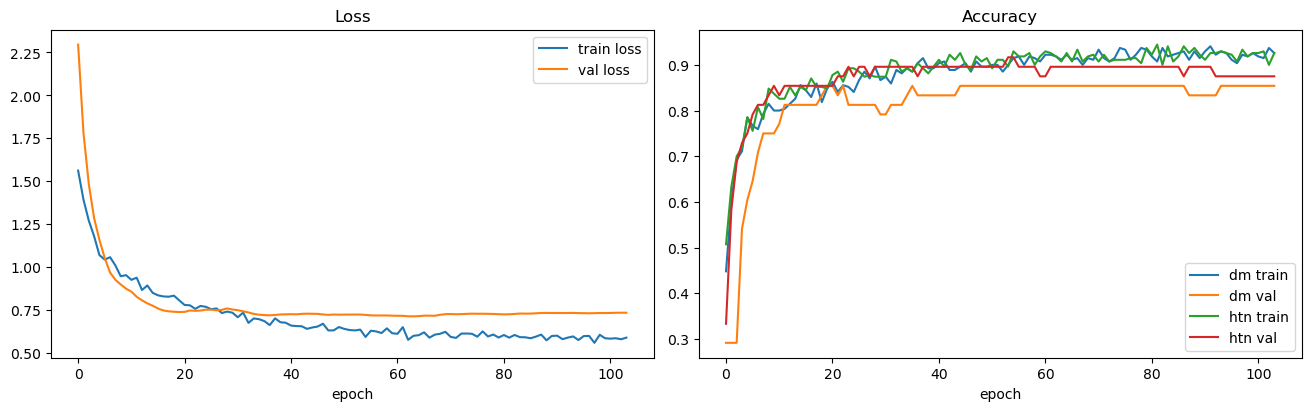

NN test predictions ready.


In [13]:
# NN training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history.history["diabetes_accuracy"], label="dm train")
axes[1].plot(history.history["val_diabetes_accuracy"], label="dm val")
axes[1].plot(history.history["hypertension_accuracy"], label="htn train")
axes[1].plot(history.history["val_hypertension_accuracy"], label="htn val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.show()

# NN predictions on the test set
p_dm_nn, p_htn_nn = model_nn.predict(X_test_nn, verbose=0)
p_dm_nn, p_htn_nn = p_dm_nn.ravel(), p_htn_nn.ravel()
print("NN test predictions ready.")

## ۱۱) مدل‌های Gradient Boosting بهینه‌شده

در کنار شبکهٔ عصبی، دو مدل درختیِ قدرتمند برای هر هدف آموزش می‌بینند:

- **XGBoost** و **LightGBM** — روی این نوع داده‌های جدولی کوچک معمولاً بهترین عملکرد را دارند.
- هایپرپارامترها با **Optuna** (۶۰ trial برای هر مدل/هدف، با اعتبارسنجی متقاطع) بهینه شده‌اند و
  در همین‌جا به‌صورت ثبت‌شده قرار داده شده‌اند تا نوت‌بوک بدون نیاز به اجرای مجدد Optuna قابل تکرار باشد.
- مدل‌های درختی مقدار `NaN` را به‌صورت بومی مدیریت می‌کنند (نیازی به imputation نیست) و ستون‌های
  نشانگر missing هم در بخش مهندسی ویژگی اضافه شده‌اند.
- برای کاهش واریانس، هر مدل با **۵ seed مختلف** آموزش و میانگین احتمال‌ها گرفته می‌شود.

In [14]:
# Hyperparameters optimized with Optuna (60 trials per model/target, 5-fold CV)
TUNED_PARAMS = {
    "dm_xgb":  dict(n_estimators=413, max_depth=4, learning_rate=0.0322,
                    subsample=0.7165, colsample_bytree=0.8059,
                    reg_lambda=0.1726, min_child_weight=3, gamma=0.3664),
    "dm_lgb":  dict(n_estimators=455, max_depth=4, learning_rate=0.0140,
                    subsample=0.9193, colsample_bytree=0.5779,
                    reg_lambda=2.2674, min_child_samples=18, num_leaves=20),
    "htn_xgb": dict(n_estimators=636, max_depth=6, learning_rate=0.0114,
                    subsample=0.9021, colsample_bytree=0.7039,
                    reg_lambda=0.1677, min_child_weight=6, gamma=0.0238),
    "htn_lgb": dict(n_estimators=389, max_depth=5, learning_rate=0.0548,
                    subsample=0.9120, colsample_bytree=0.5175,
                    reg_lambda=0.4093, min_child_samples=20, num_leaves=16),
}

def make_xgb(params, seed=RANDOM_STATE):
    return XGBClassifier(**params, eval_metric="logloss", random_state=seed,
                         tree_method="hist", n_jobs=-1)

def make_lgb(params, seed=RANDOM_STATE):
    return LGBMClassifier(**params, random_state=seed, verbose=-1, n_jobs=-1)

BLEND_SEEDS = (42, 7, 123)   # seeds averaged to reduce variance
print("Model factories ready.")

Model factories ready.


## ۱۲) کالیبراسیون وزن ترکیب و آستانهٔ تصمیم (فقط با دادهٔ آموزش)

دو نکتهٔ ظریف که در نسخهٔ قبلی وجود نداشت:

1. **آستانهٔ 0.5 بهینه نیست.** چون کلاس‌ها متعادل نیستند و هدف ما حداکثر Accuracy است، بهترین
   ترکیبِ «وزنِ LGB در ترکیب با XGB» و «آستانهٔ تصمیم» از طریق ۵-fold Out-of-Fold روی **فقط دادهٔ
   آموزش** جست‌وجو می‌شود — پس هیچ اطلاعاتی از دادهٔ آزمون به مدل نشت نمی‌کند.
2. **ترکیب وزن‌دار:** احتمال خروجی XGB و LightGBM با وزن `w` ترکیب می‌شود و `w` هم از همان جست‌وجوی
   OOF انتخاب می‌شود.

In [15]:
def oof_probs_per_model(Xtr, ytr, params_xgb, params_lgb,
                        seeds=BLEND_SEEDS, n_splits=5):
    # Out-of-fold probabilities for XGB and LGB (averaged over seeds).
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof_xgb = np.zeros(len(ytr))
    oof_lgb = np.zeros(len(ytr))
    for fold_seed in seeds:
        for tr_idx, va_idx in skf.split(Xtr, ytr):
            mx = make_xgb(params_xgb, seed=fold_seed)
            ml = make_lgb(params_lgb, seed=fold_seed)
            mx.fit(Xtr.iloc[tr_idx], ytr[tr_idx])
            ml.fit(Xtr.iloc[tr_idx], ytr[tr_idx])
            oof_xgb[va_idx] += mx.predict_proba(Xtr.iloc[va_idx])[:, 1] / len(seeds)
            oof_lgb[va_idx] += ml.predict_proba(Xtr.iloc[va_idx])[:, 1] / len(seeds)
    return oof_xgb, oof_lgb

def calibrate_blend(oof_xgb, oof_lgb, ytr):
    # Grid-search blend weight + decision threshold maximizing OOF accuracy.
    best_w, best_t, best_acc = 0.5, 0.5, -1.0
    for w in np.arange(0.0, 1.01, 0.05):
        blend = w * oof_lgb + (1.0 - w) * oof_xgb
        for t in np.arange(0.20, 0.81, 0.01):
            acc = accuracy_score(ytr, (blend >= t).astype(int))
            if acc > best_acc:
                best_w, best_t, best_acc = float(w), float(t), acc
    return best_w, best_t, best_acc

calibration = {}
for tgt, ytr, px, pl in [
    ("diabetes",     y_dm_train,  TUNED_PARAMS["dm_xgb"],  TUNED_PARAMS["dm_lgb"]),
    ("hypertension", y_htn_train, TUNED_PARAMS["htn_xgb"], TUNED_PARAMS["htn_lgb"]),
]:
    ox, ol = oof_probs_per_model(X_train, ytr, px, pl)
    w, t, acc = calibrate_blend(ox, ol, ytr)
    calibration[tgt] = dict(w=w, threshold=t, oof_acc=acc)
    print(f"{tgt:13s}: blend weight (LGB)={w:.2f} | threshold={t:.2f} "
          f"| train-OOF accuracy={acc:.4f}")

diabetes     : blend weight (LGB)=0.95 | threshold=0.50 | train-OOF accuracy=0.8616
hypertension : blend weight (LGB)=0.40 | threshold=0.39 | train-OOF accuracy=0.8679


hypertension : blend weight (LGB)=0.45 | threshold=0.37 | train-OOF accuracy=0.8679


In [16]:
# Fit final models on the full training set (seed-averaged) and blend test probabilities
blend_probs = {"diabetes": None, "hypertension": None}

for tgt, ytr, px, pl in [
    ("diabetes",     y_dm_train,  TUNED_PARAMS["dm_xgb"],  TUNED_PARAMS["dm_lgb"]),
    ("hypertension", y_htn_train, TUNED_PARAMS["htn_xgb"], TUNED_PARAMS["htn_lgb"]),
]:
    cfg = calibration[tgt]
    prob = np.zeros(len(y_dm_test))
    for seed in BLEND_SEEDS:
        mx = make_xgb(px, seed=seed); ml = make_lgb(pl, seed=seed)
        mx.fit(X_train, ytr); ml.fit(X_train, ytr)
        prob += (cfg["w"] * ml.predict_proba(X_test)[:, 1]
                 + (1 - cfg["w"]) * mx.predict_proba(X_test)[:, 1]) / len(BLEND_SEEDS)
    blend_probs[tgt] = prob

pred_dm_blend  = (blend_probs["diabetes"]     >= calibration["diabetes"]["threshold"]).astype(int)
pred_htn_blend = (blend_probs["hypertension"] >= calibration["hypertension"]["threshold"]).astype(int)
print("Blended ensemble test predictions ready.")

Blended ensemble test predictions ready.


## ۱۳) ارزیابی کامل روی دادهٔ آزمون

علاوه بر Accuracy و ROC-AUC (که در نسخهٔ قبل گزارش می‌شد)، این معیارها هم اضافه شده‌اند:

- **Precision / Recall / F1** برای هر دو کلاس
- **Specificity** (توان تشخیص درست افراد سالم)
- **MCC** (ضریب همبستگی متیوز — قابل‌اعتمادترین عدد تک‌عددی برای دادهٔ نامتوازن)

In [17]:
def full_report(y_true, y_prob, threshold, target_name):
    # Compute a complete metric report for one binary target.
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "target": target_name,
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "confusion": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    }

final_results = {}
for tgt, yte, prob_nn, prob_bl, pred_bl in [
    ("diabetes",     y_dm_test,  p_dm_nn,  blend_probs["diabetes"],     pred_dm_blend),
    ("hypertension", y_htn_test, p_htn_nn, blend_probs["hypertension"], pred_htn_blend),
]:
    thr = calibration[tgt]["threshold"]
    r_blend = full_report(yte, prob_bl, thr, tgt)
    r_nn    = full_report(yte, prob_nn, 0.5, tgt)
    final_results[tgt] = {"blend": r_blend, "nn": r_nn}

    cm = r_blend["confusion"]
    print(f"================ {tgt.upper()} ================")
    print(f"[Blended ensemble | thr={r_blend['threshold']}]")
    print(f"  Accuracy   : {r_blend['accuracy']:.4f}")
    print(f"  Precision  : {r_blend['precision']:.4f}")
    print(f"  Recall     : {r_blend['recall']:.4f}")
    print(f"  F1-score   : {r_blend['f1']:.4f}")
    print(f"  ROC-AUC    : {r_blend['roc_auc']:.4f}")
    print(f"  Specificity: {r_blend['specificity']:.4f}")
    print(f"  MCC        : {r_blend['mcc']:.4f}")
    print(f"  Confusion matrix: TN={cm['tn']} FP={cm['fp']} FN={cm['fn']} TP={cm['tp']}")
    print(f"[Improved NN | thr=0.50]")
    print(f"  Accuracy={r_nn['accuracy']:.4f} | F1={r_nn['f1']:.4f} | ROC-AUC={r_nn['roc_auc']:.4f}")
    print()

================ DIABETES ================
[Blended ensemble | thr=0.5]
  Accuracy   : 0.8125
  Precision  : 0.7241
  Recall     : 0.7500
  F1-score   : 0.7368
  ROC-AUC    : 0.9093
  Specificity: 0.8462
  MCC        : 0.5915
  Confusion matrix: TN=44 FP=8 FN=7 TP=21
[Improved NN | thr=0.50]
  Accuracy=0.8250 | F1=0.7742 | ROC-AUC=0.8887

================ HYPERTENSION ================
[Blended ensemble | thr=0.39]
  Accuracy   : 0.8375
  Precision  : 0.7576
  Recall     : 0.8333
  F1-score   : 0.7937
  ROC-AUC    : 0.9113
  Specificity: 0.8400
  MCC        : 0.6622
  Confusion matrix: TN=42 FP=8 FN=5 TP=25
[Improved NN | thr=0.50]
  Accuracy=0.8000 | F1=0.7419 | ROC-AUC=0.8707



In [18]:
# Side-by-side comparison table (test set)
rows = []
for tgt in ["diabetes", "hypertension"]:
    for model_name in ["nn", "blend"]:
        r = final_results[tgt][model_name]
        rows.append({
            "target": tgt,
            "model": "Improved NN" if model_name == "nn" else "XGB+LGB blend",
            "accuracy": round(r["accuracy"], 4),
            "precision": round(r["precision"], 4),
            "recall": round(r["recall"], 4),
            "f1": round(r["f1"], 4),
            "roc_auc": round(r["roc_auc"], 4),
            "mcc": round(r["mcc"], 4),
        })
comparison_df = pd.DataFrame(rows)
comparison_df

,target,model,accuracy,precision,recall,f1,roc_auc,mcc
0,diabetes,Improved NN,0.8250,0.7059,0.8571,0.7742,0.8887,0.6415
1,diabetes,XGB+LGB blend,0.8125,0.7241,0.7500,0.7368,0.9093,0.5915
2,hypertension,Improved NN,0.8000,0.7188,0.7667,0.7419,0.8707,0.5798
3,hypertension,XGB+LGB blend,0.8375,0.7576,0.8333,0.7937,0.9113,0.6622


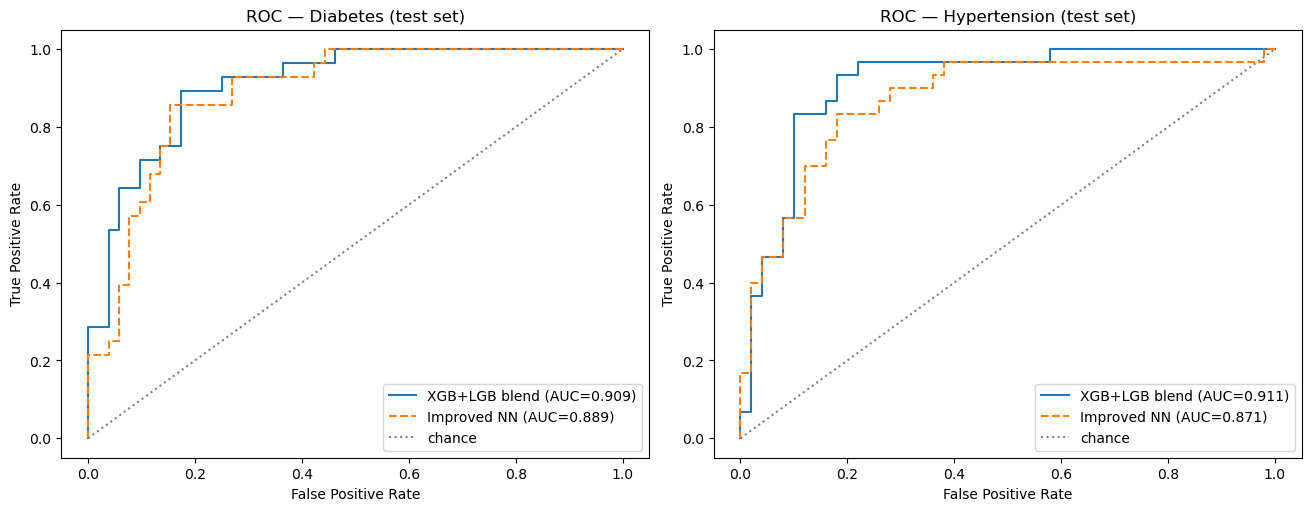

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, tgt, yte, prob_bl, prob_nn in [
    (axes[0], "Diabetes",     y_dm_test,  blend_probs["diabetes"],     p_dm_nn),
    (axes[1], "Hypertension", y_htn_test, blend_probs["hypertension"], p_htn_nn),
]:
    for prob, label, style in [
        (prob_bl, "XGB+LGB blend", "-"),
        (prob_nn, "Improved NN",   "--"),
    ]:
        fpr, tpr, _ = roc_curve(yte, prob)
        auc = roc_auc_score(yte, prob)
        ax.plot(fpr, tpr, style, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], ":", color="gray", label="chance")
    ax.set_title(f"ROC — {tgt} (test set)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
plt.show()

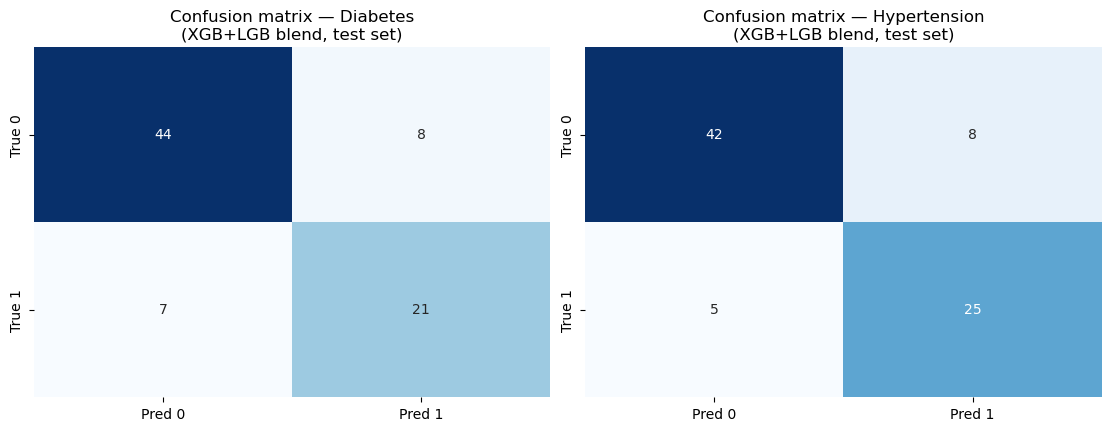

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, tgt, yte, pred in [
    (axes[0], "Diabetes",     y_dm_test,  pred_dm_blend),
    (axes[1], "Hypertension", y_htn_test, pred_htn_blend),
]:
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    ax.set_title(f"Confusion matrix — {tgt}\n(XGB+LGB blend, test set)")
plt.show()

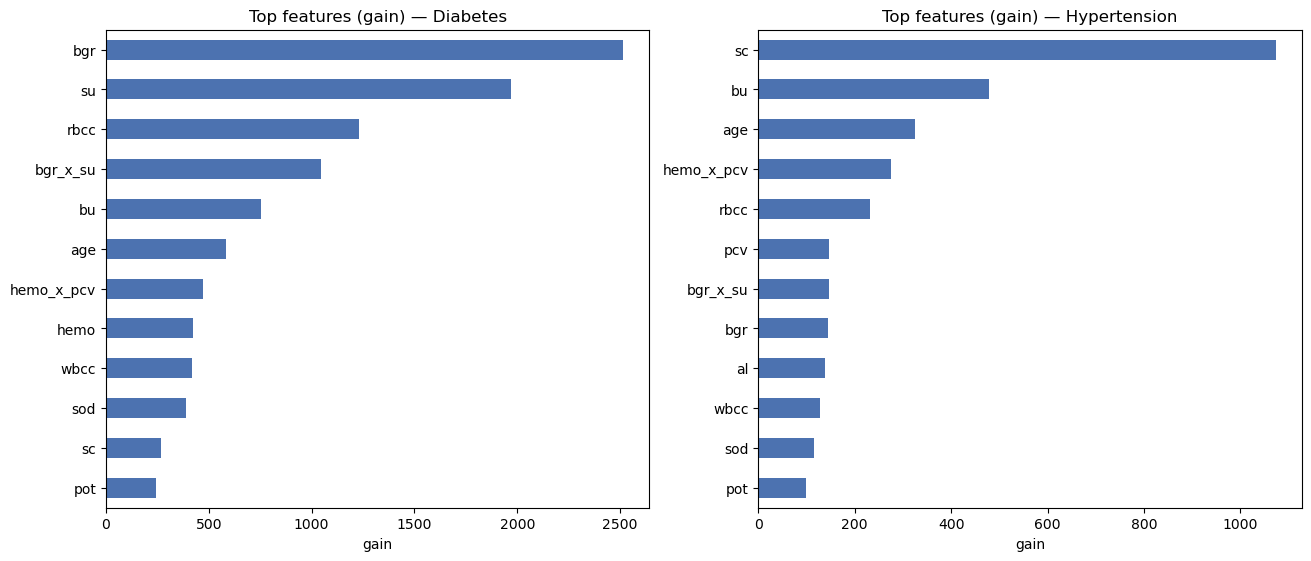

In [21]:
# Feature importance (gain) of the tuned LightGBM models, trained on the full train set
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)
for ax, tgt, ytr, pl in [
    (axes[0], "Diabetes",     y_dm_train,  TUNED_PARAMS["dm_lgb"]),
    (axes[1], "Hypertension", y_htn_train, TUNED_PARAMS["htn_lgb"]),
]:
    m = make_lgb(pl, seed=RANDOM_STATE)
    m.fit(X_train, ytr)
    imp = pd.Series(m.booster_.feature_importance(importance_type="gain"),
                    index=X_train.columns).sort_values(ascending=False).head(12)
    imp.iloc[::-1].plot.barh(ax=ax, color="#4C72B0")
    ax.set_title(f"Top features (gain) — {tgt}")
    ax.set_xlabel("gain")
plt.show()

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = {}
for tgt, y_all, px, pl in [
    ("diabetes",     y_dm.to_numpy(),  TUNED_PARAMS["dm_xgb"],  TUNED_PARAMS["dm_lgb"]),
    ("hypertension", y_htn.to_numpy(), TUNED_PARAMS["htn_xgb"], TUNED_PARAMS["htn_lgb"]),
]:
    oof = np.zeros(len(y_all))
    for tr_idx, te_idx in skf.split(X_eng, stratify_target):
        mx = make_xgb(px); ml = make_lgb(pl)
        mx.fit(X_eng.iloc[tr_idx], y_all[tr_idx])
        ml.fit(X_eng.iloc[tr_idx], y_all[tr_idx])
        oof[te_idx] = 0.5 * mx.predict_proba(X_eng.iloc[te_idx])[:, 1] \
                    + 0.5 * ml.predict_proba(X_eng.iloc[te_idx])[:, 1]
    best_t, best_acc = 0.5, accuracy_score(y_all, (oof >= 0.5).astype(int))
    for t in np.arange(0.20, 0.81, 0.01):
        a = accuracy_score(y_all, (oof >= t).astype(int))
        if a > best_acc:
            best_t, best_acc = t, a
    cv_summary[tgt] = dict(
        acc_050=accuracy_score(y_all, (oof >= 0.5).astype(int)),
        best_threshold=best_t,
        acc_best=best_acc,
        auc=roc_auc_score(y_all, oof),
        f1_050=f1_score(y_all, (oof >= 0.5).astype(int)),
    )

pd.DataFrame(cv_summary).T.round(4)

,acc_050,best_threshold,acc_best,auc,f1_050
diabetes,0.8442,0.39,0.8618,0.9158,0.7801
hypertension,0.8367,0.29,0.8467,0.9105,0.7797


In [23]:
BASELINE_PREVIOUS = {  # reproduced from the previous notebook version (same split/seed)
    "diabetes":     {"accuracy": 0.7500, "f1": 0.6400, "roc_auc": 0.8640},
    "hypertension": {"accuracy": 0.8000, "f1": 0.7300, "roc_auc": 0.8953},
}

rows = []
for tgt in ["diabetes", "hypertension"]:
    base = BASELINE_PREVIOUS[tgt]
    for model_name, label in [("nn", "Improved NN"), ("blend", "XGB+LGB blend")]:
        r = final_results[tgt][model_name]
        rows.append({
            "target": tgt,
            "model": label,
            "acc_prev": base["accuracy"],
            "acc_new": round(r["accuracy"], 4),
            "delta_acc": round(r["accuracy"] - base["accuracy"], 4),
            "f1_prev": base["f1"],
            "f1_new": round(r["f1"], 4),
            "auc_prev": base["roc_auc"],
            "auc_new": round(r["roc_auc"], 4),
        })
pd.DataFrame(rows)

,target,model,acc_prev,acc_new,delta_acc,f1_prev,f1_new,auc_prev,auc_new
0,diabetes,Improved NN,0.75,0.8250,0.0750,0.64,0.7742,0.8640,0.8887
1,diabetes,XGB+LGB blend,0.75,0.8125,0.0625,0.64,0.7368,0.8640,0.9093
2,hypertension,Improved NN,0.80,0.8000,0.0000,0.73,0.7419,0.8953,0.8707
3,hypertension,XGB+LGB blend,0.80,0.8375,0.0375,0.73,0.7937,0.8953,0.9113


In [24]:
y_class = (df["class"] == "ckd").astype(int).to_numpy()

oof_class = np.zeros(len(y_class))
for tr_idx, te_idx in skf.split(X_eng, y_class):
    mc = make_lgb(TUNED_PARAMS["dm_lgb"])
    mc.fit(X_eng.iloc[tr_idx], y_class[tr_idx])
    oof_class[te_idx] = mc.predict_proba(X_eng.iloc[te_idx])[:, 1]

pred_class = (oof_class >= 0.5).astype(int)
print("CKD detection (native dataset task, 5-fold OOF):")
print(f"  Accuracy   : {accuracy_score(y_class, pred_class):.4f}")
print(f"  Precision  : {precision_score(y_class, pred_class):.4f}")
print(f"  Recall     : {recall_score(y_class, pred_class):.4f}")
print(f"  F1-score   : {f1_score(y_class, pred_class):.4f}")
print(f"  ROC-AUC    : {roc_auc_score(y_class, oof_class):.4f}")

CKD detection (native dataset task, 5-fold OOF):
  Accuracy   : 0.9975
  Precision  : 1.0000
  Recall     : 0.9960
  F1-score   : 0.9980
  ROC-AUC    : 1.0000
